# Exercise 4 Digitization and Data Analytics

## Unsupervised Learning with the Iris Data Set

Content

- Fundamental concepts in interaction with Apache Spark
- Working with Jupyter Notebooks
- Usage of basic algorithms (clustering) from the machine learning library spark ML Library

Preparation of Spark
1. Ensure Java 17 is installed and `JAVA_HOME` is set to `/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home`.
2. Restart the notebook kernel before running the next code cell.
3. The following cell clears old Spark environment variables and starts a local SparkSession.


Preparation of your jupyter notebook and the necessary data

1. Prepare a machine learning directory 

2. Download `kmeans_iris_csv_local.ipynb` and `iris.csv` into the `DDA/DDA EXERCISE/Exercise 5` folder.
3. Run the next code cell to clear stale Spark environment variables, set `JAVA_HOME`, and start a local SparkSession.


In [1]:
%matplotlib inline
import os
from pathlib import Path
cwd = Path.cwd()
irisDataPath = cwd / "iris.csv"
if not irisDataPath.exists():
    irisDataPath = cwd / "DDA" / "DDA EXERCISE" / "Exercise 5" / "iris.csv"
if not irisDataPath.exists():
    raise FileNotFoundError(f"iris.csv file not found at {irisDataPath}")
irisDataPath = str(irisDataPath)
print("irisDataPath=", irisDataPath)
for key in ("SPARK_HOME", "PYSPARK_HOME", "PYSPARK_DRIVER_PYTHON", "PYSPARK_PYTHON"):
    os.environ.pop(key, None)
os.environ["JAVA_HOME"] = "/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home"
import platform
print("the python version is: " + platform.python_version())
print("SPARK_HOME=", os.environ.get("SPARK_HOME"))
print("JAVA_HOME=", os.environ.get("JAVA_HOME"))
from pyspark.sql import SparkSession
spark = SparkSession.builder.master("local[*]").appName("KMeansIris").getOrCreate()


irisDataPath= /Users/krishnakumarm/Downloads/TU Dresden MS CS/Semester 1/DDA/DDA EXERCISE/Exercise 5/iris.csv
the python version is: 3.12.13
SPARK_HOME= None
JAVA_HOME= /opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/11 12:07:06 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
from pyspark.ml.clustering import KMeans
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
from pyspark.sql.types import DoubleType, StructType, StructField, StringType

In [3]:
# create explicit spark context 
# spark = SparkSession.builder.appName("PythonKMeansIris").getOrCreate()


1. Read the overview on DataFrames: https://spark.apache.org/docs/latest/sql-programming-guide.html#datasets-and-dataframes 
2. Have a look into the input file first manually (use editor or command on shell). In the following piece of code a DataFrame is generated, and the csv-file is parsed. A VectorAssembler is defined and used to transform the input DataFrame into an dataset. 

In [4]:
# generate DataFrame, use DataFrameReader class to parse csv input
dataframe = spark.read.csv(irisDataPath, header=True, schema=StructType([
    StructField("sepal_length", DoubleType(), True),
    StructField("sepal_width", DoubleType(), True),
    StructField("petal_length", DoubleType(), True),
    StructField("petal_width", DoubleType(), True),
    StructField("spezies", StringType(), True)
]))
# define a corresponding vector assembler
assembler = VectorAssembler(inputCols=["sepal_length", "sepal_width", "petal_length", "petal_width"],
                             outputCol="features")
dataset = assembler.transform(dataframe)


In [5]:
#show parameters: 
assembler.params

[Param(parent='VectorAssembler_6d71c874f807', name='handleInvalid', doc="How to handle invalid data (NULL and NaN values). Options are 'skip' (filter out rows with invalid data), 'error' (throw an error), or 'keep' (return relevant number of NaN in the output). Column lengths are taken from the size of ML Attribute Group, which can be set using `VectorSizeHint` in a pipeline before `VectorAssembler`. Column lengths can also be inferred from first rows of the data since it is safe to do so but only in case of 'error' or 'skip')."),
 Param(parent='VectorAssembler_6d71c874f807', name='inputCols', doc='input column names.'),
 Param(parent='VectorAssembler_6d71c874f807', name='outputCol', doc='output column name.')]

In [6]:
assembler.explainParams()

"handleInvalid: How to handle invalid data (NULL and NaN values). Options are 'skip' (filter out rows with invalid data), 'error' (throw an error), or 'keep' (return relevant number of NaN in the output). Column lengths are taken from the size of ML Attribute Group, which can be set using `VectorSizeHint` in a pipeline before `VectorAssembler`. Column lengths can also be inferred from first rows of the data since it is safe to do so but only in case of 'error' or 'skip'). (default: error)\ninputCols: input column names. (current: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width'])\noutputCol: output column name. (default: VectorAssembler_6d71c874f807__output, current: features)"

**Exercise:** Examine the data structure of the DataFrame by utilizing the functions 'first', 'head', 'show' and 'printSchema'.

In [7]:
dataframe.show(10, truncate=False)
dataframe.printSchema()
print("Row count:", dataframe.count())
print("First row:", dataframe.first())


26/06/11 12:07:10 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: 5.1, 3.5, 1.4, 0.2, Iris-setosa
 Schema: sepal_length, sepal_width, petal_length, petal_width, spezies
Expected: sepal_length but found: 5.1
CSV file: file:///Users/krishnakumarm/Downloads/TU%20Dresden%20MS%20CS/Semester%201/DDA/DDA%20EXERCISE/Exercise%205/iris.csv


+------------+-----------+------------+-----------+-----------+
|sepal_length|sepal_width|petal_length|petal_width|spezies    |
+------------+-----------+------------+-----------+-----------+
|4.9         |3.0        |1.4         |0.2        |Iris-setosa|
|4.7         |3.2        |1.3         |0.2        |Iris-setosa|
|4.6         |3.1        |1.5         |0.2        |Iris-setosa|
|5.0         |3.6        |1.4         |0.2        |Iris-setosa|
|5.4         |3.9        |1.7         |0.4        |Iris-setosa|
|4.6         |3.4        |1.4         |0.3        |Iris-setosa|
|5.0         |3.4        |1.5         |0.2        |Iris-setosa|
|4.4         |2.9        |1.4         |0.2        |Iris-setosa|
|4.9         |3.1        |1.5         |0.1        |Iris-setosa|
|5.4         |3.7        |1.5         |0.2        |Iris-setosa|
+------------+-----------+------------+-----------+-----------+
only showing top 10 rows
root
 |-- sepal_length: double (nullable = true)
 |-- sepal_width: double (null

26/06/11 12:07:10 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: 5.1, 3.5, 1.4, 0.2, Iris-setosa
 Schema: sepal_length, sepal_width, petal_length, petal_width, spezies
Expected: sepal_length but found: 5.1
CSV file: file:///Users/krishnakumarm/Downloads/TU%20Dresden%20MS%20CS/Semester%201/DDA/DDA%20EXERCISE/Exercise%205/iris.csv


**Exercise:** Prepare the data for plotting using e.g. 'matplotlib' package. Plot a scatterplot of the sepal dimension and a second one for the petal dimension.

**Hint:** Convert Spark DataFrame to Pandas dataframe object for plotting.

26/06/11 12:07:10 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: 5.1, 3.5, 1.4, 0.2, Iris-setosa
 Schema: sepal_length, sepal_width, petal_length, petal_width, spezies
Expected: sepal_length but found: 5.1
CSV file: file:///Users/krishnakumarm/Downloads/TU%20Dresden%20MS%20CS/Semester%201/DDA/DDA%20EXERCISE/Exercise%205/iris.csv


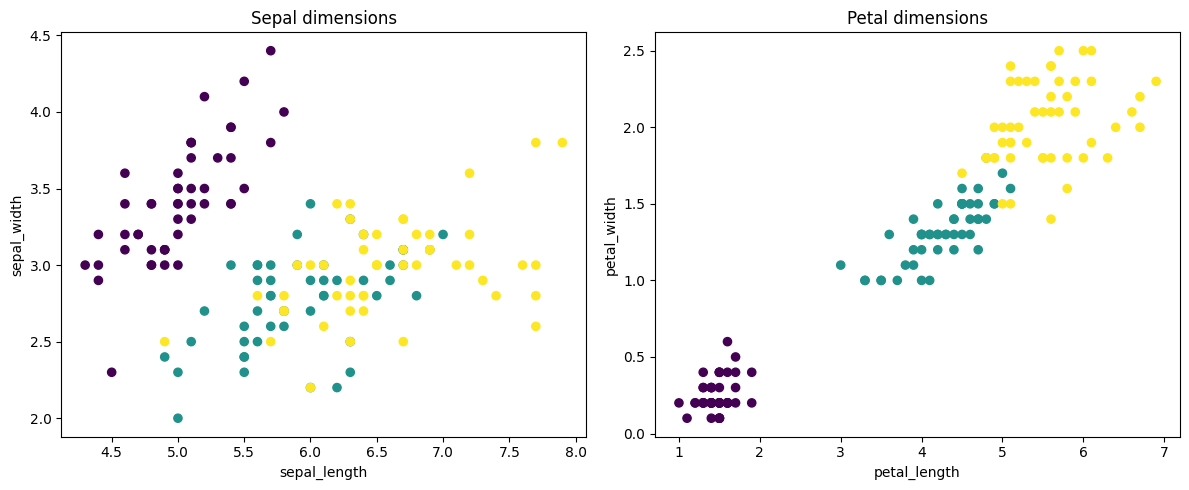

In [8]:
import matplotlib.pyplot as plt
plot_df = dataframe.toPandas()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(plot_df["sepal_length"], plot_df["sepal_width"], c=plot_df["spezies"].astype("category").cat.codes, cmap="viridis", s=35)
axes[0].set_xlabel("sepal_length")
axes[0].set_ylabel("sepal_width")
axes[0].set_title("Sepal dimensions")
axes[1].scatter(plot_df["petal_length"], plot_df["petal_width"], c=plot_df["spezies"].astype("category").cat.codes, cmap="viridis", s=35)
axes[1].set_xlabel("petal_length")
axes[1].set_ylabel("petal_width")
axes[1].set_title("Petal dimensions")
fig.tight_layout()
plt.show()


**Question** How many clusters would you expect in the data set?

Expected number of clusters: 3 (Iris dataset contains three species).


**Exercise:** Define a k-means-Model and fit it on the dataset with your prediction of numbers of clusters using the setK(N) methods, where N sets the number of expected clusters.

In [9]:
k = 3
kmeans = KMeans(featuresCol="features", predictionCol="prediction", k=k, seed=42)
model = kmeans.fit(dataset)
predictions = model.transform(dataset)
print("Cluster centers:")
for i, center in enumerate(model.clusterCenters()):
    print(f"Center {i}: {center}")
if hasattr(model, "summary") and model.summary is not None:
    print("Within Set Sum of Squared Errors:", model.summary.trainingCost)
else:
    print("Within Set Sum of Squared Errors:", model.computeCost(dataset))
predictions.groupBy("prediction").count().orderBy("prediction").show()


26/06/11 12:07:11 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: 5.1, 3.5, 1.4, 0.2
 Schema: sepal_length, sepal_width, petal_length, petal_width
Expected: sepal_length but found: 5.1
CSV file: file:///Users/krishnakumarm/Downloads/TU%20Dresden%20MS%20CS/Semester%201/DDA/DDA%20EXERCISE/Exercise%205/iris.csv
26/06/11 12:07:11 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: 5.1, 3.5, 1.4, 0.2
 Schema: sepal_length, sepal_width, petal_length, petal_width
Expected: sepal_length but found: 5.1
CSV file: file:///Users/krishnakumarm/Downloads/TU%20Dresden%20MS%20CS/Semester%201/DDA/DDA%20EXERCISE/Exercise%205/iris.csv
26/06/11 12:07:11 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: 5.1, 3.5, 1.4, 0.2
 Schema: sepal_length, sepal_width, petal_length, petal_width
Expected: sepal_length but found: 5.1
CSV file: file:///Users/krishnakumarm/Downloads/TU%20Dresden%20MS%20CS/Semester%201/DDA/DDA%20EXERCISE/Exercise%20

Cluster centers:
Center 0: [5.88360656 2.74098361 4.38852459 1.43442623]
Center 1: [5.00408163 3.41632653 1.46530612 0.24489796]
Center 2: [6.85384615 3.07692308 5.71538462 2.05384615]
Within Set Sum of Squared Errors: 78.92303317291605
+----------+-----+
|prediction|count|
+----------+-----+
|         0|   61|
|         1|   49|
|         2|   39|
+----------+-----+



Evaluate the result, e.g. by computing "Within Set Sum of Squared Errors" and have a look to the clusters.

**Exercise:** Compare the result obtained with the k-means algorithm to the ground truth by performing the steps described in the following.

1. Display the cluster centers found with the k-mean algorithm.     
2. Plot your data in the same plot, and visualize the given classes.     
3. Discuss the outcome.

26/06/11 12:07:12 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: 5.1, 3.5, 1.4, 0.2, Iris-setosa
 Schema: sepal_length, sepal_width, petal_length, petal_width, spezies
Expected: sepal_length but found: 5.1
CSV file: file:///Users/krishnakumarm/Downloads/TU%20Dresden%20MS%20CS/Semester%201/DDA/DDA%20EXERCISE/Exercise%205/iris.csv
26/06/11 12:07:12 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: 5.1, 3.5, 1.4, 0.2, Iris-setosa
 Schema: sepal_length, sepal_width, petal_length, petal_width, spezies
Expected: sepal_length but found: 5.1
CSV file: file:///Users/krishnakumarm/Downloads/TU%20Dresden%20MS%20CS/Semester%201/DDA/DDA%20EXERCISE/Exercise%205/iris.csv


+-----------+----------+----------+
|spezies    |species_id|prediction|
+-----------+----------+----------+
|Iris-setosa|0         |1         |
|Iris-setosa|0         |1         |
|Iris-setosa|0         |1         |
|Iris-setosa|0         |1         |
|Iris-setosa|0         |1         |
|Iris-setosa|0         |1         |
|Iris-setosa|0         |1         |
|Iris-setosa|0         |1         |
|Iris-setosa|0         |1         |
|Iris-setosa|0         |1         |
+-----------+----------+----------+
only showing top 10 rows
+---------------+----------+-----+
|spezies        |prediction|count|
+---------------+----------+-----+
|Iris-setosa    |1         |49   |
|Iris-versicolor|0         |47   |
|Iris-versicolor|2         |3    |
|Iris-virginica |0         |14   |
|Iris-virginica |2         |36   |
+---------------+----------+-----+



26/06/11 12:07:13 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: 5.1, 3.5, 1.4, 0.2, Iris-setosa
 Schema: sepal_length, sepal_width, petal_length, petal_width, spezies
Expected: sepal_length but found: 5.1
CSV file: file:///Users/krishnakumarm/Downloads/TU%20Dresden%20MS%20CS/Semester%201/DDA/DDA%20EXERCISE/Exercise%205/iris.csv


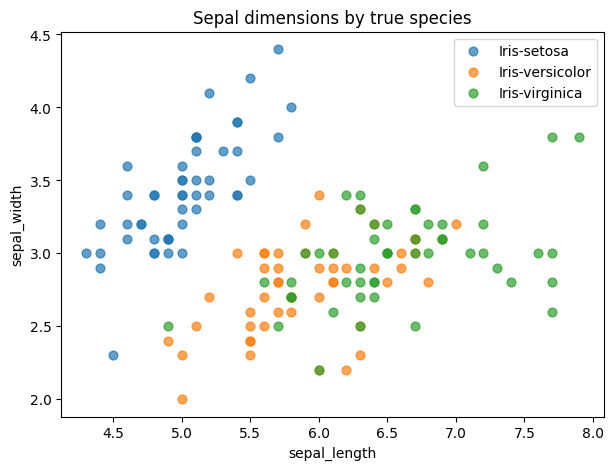

26/06/11 12:07:13 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: 5.1, 3.5, 1.4, 0.2
 Schema: sepal_length, sepal_width, petal_length, petal_width
Expected: sepal_length but found: 5.1
CSV file: file:///Users/krishnakumarm/Downloads/TU%20Dresden%20MS%20CS/Semester%201/DDA/DDA%20EXERCISE/Exercise%205/iris.csv


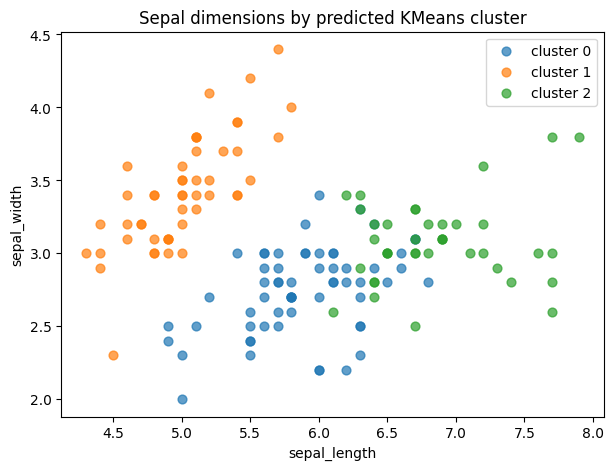

In [10]:
from pyspark.sql.functions import col, when
predictions = predictions.withColumn(
    "species_id",
    when(col("spezies") == "Iris-setosa", 0)
    .when(col("spezies") == "Iris-versicolor", 1)
    .when(col("spezies") == "Iris-virginica", 2)
    .otherwise(-1)
)
predictions.select("spezies", "species_id", "prediction").show(10, truncate=False)
predictions.groupBy("spezies", "prediction").count().orderBy("spezies", "prediction").show(20, truncate=False)
plot_df = predictions.select("sepal_length", "sepal_width", "spezies", "prediction").toPandas()
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
for species, group in plot_df.groupby("spezies"):
    ax.scatter(group["sepal_length"], group["sepal_width"], label=species, alpha=0.7, s=40)
ax.set_xlabel("sepal_length")
ax.set_ylabel("sepal_width")
ax.set_title("Sepal dimensions by true species")
ax.legend()
plt.show()

plot_df_pred = predictions.select("sepal_length", "sepal_width", "prediction").toPandas()
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
for cluster, group in plot_df_pred.groupby("prediction"):
    ax.scatter(group["sepal_length"], group["sepal_width"], label=f"cluster {cluster}", alpha=0.7, s=40)
ax.set_xlabel("sepal_length")
ax.set_ylabel("sepal_width")
ax.set_title("Sepal dimensions by predicted KMeans cluster")
ax.legend()
plt.show()


**Discussion:**

- KMeans with `k=3` is appropriate because the Iris dataset has three natural species.
- The algorithm finds one cluster that matches `Iris-setosa` very well, while `Iris-versicolor` and `Iris-virginica` overlap more and may be split differently.
- A contingency table shows the cluster-label relationship and helps identify which cluster corresponds to which species.
- Three distinct colors are appropriate for the Iris species and for the three predicted clusters.

The predicted clusters are determined by feature similarity, not by the original species labels, so exact label alignment may differ by cluster index permutation.

In [11]:
spark.stop()